In [1]:
import pandas as pd
import os

In [2]:
import torch

print("CUDA version in PyTorch:", torch.version.cuda)
print("Is CUDA available?", torch.cuda.is_available())
print(torch.cuda.get_device_name(0))
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CUDA version in PyTorch: 12.1
Is CUDA available? True
NVIDIA GeForce RTX 3090


In [3]:
matches = pd.read_csv("../feature_creation/data/atp_matches_model_ready.csv")

In [4]:
list(matches.columns)


['tournament_id',
 'tournament_location',
 'draw_size',
 'tournament_date',
 'match_num',
 'score',
 'best_of',
 'round',
 'minutes',
 'w_ace',
 'w_df',
 'w_svpt',
 'w_1stIn',
 'w_1stWon',
 'w_2ndWon',
 'w_SvGms',
 'w_bpSaved',
 'w_bpFaced',
 'l_ace',
 'l_df',
 'l_svpt',
 'l_1stIn',
 'l_1stWon',
 'l_2ndWon',
 'l_SvGms',
 'l_bpSaved',
 'l_bpFaced',
 'year',
 'shortened_winner_name',
 'shortened_loser_name',
 'match_id',
 'Date',
 'W1',
 'W2',
 'W3',
 'W4',
 'W5',
 'L1',
 'L2',
 'L3',
 'L4',
 'L5',
 'Wsets',
 'Lsets',
 'Comment',
 'elo_pwin',
 'surface_elo_pwin',
 'blended_elo_pwin',
 'elo_diff',
 'surface_elo_diff',
 'blended_elo_diff',
 'surface_Clay',
 'surface_Grass',
 'surface_Hard',
 'tournament_level_ATP250',
 'tournament_level_ATP500',
 'tournament_level_Grand Slam',
 'tournament_level_Masters 1000',
 'outdoor',
 'target',
 'player1_id',
 'player2_id',
 'player1_name',
 'player2_name',
 'player1_ht',
 'player2_ht',
 'player1_ioc',
 'player2_ioc',
 'player1_age',
 'player2_age',
 

In [5]:
matches.shape


(22092, 128)

In [6]:
matches['Date'] = pd.to_datetime(matches['Date'])
matches['year'] = matches['Date'].dt.year
matches = matches[matches['year'] > 2014]

In [7]:
train_matches = matches[matches['year'] < 2022]
val_matches = matches[matches['year'] == 2022]
test_matches = matches[matches['year'] == 2023]

In [8]:
player1_info_cols = ['player1_surface_elo', 'player1_elo', 'player1_is_right_handed', 'player1_entry_LL', 'player1_entry_Q', 'player1_entry_WC',
                     'player1_ht', 'player1_age','player1_fatigue_score', 'player1_h2h_wins',
                     'player1_best_result_tournament_history', 'player1_last_result_tournament_history', 'player1_average_result_tournament_history',
                     'player1_round_level_win_pct', 'player1_round_level_appearances']
player2_info_cols = ['player2_surface_elo', 'player2_elo', 'player2_is_right_handed', 'player2_entry_LL', 'player2_entry_Q', 'player2_entry_WC',
                     'player2_ht', 'player2_age','player2_fatigue_score', 'player2_h2h_wins',
                     'player2_best_result_tournament_history', 'player2_last_result_tournament_history', 'player2_average_result_tournament_history',
                     'player2_round_level_win_pct', 'player2_round_level_appearances']

env_cols = ['tournament_level_ATP250', 'tournament_level_ATP500', 'tournament_level_Masters 1000',
         'tournament_level_Grand Slam','outdoor', 'surface_Grass', 'surface_Hard', 'surface_Clay']

## GRU for form

In [9]:
import torch.nn as nn

class GRUFormEncoder(nn.Module):

    def __init__(self, input_size, hidden_size, num_layers=1, dropout=0.0):
        super().__init__()
        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

    def forward(self, x):
        gru_out, _ = self.gru(x)

        context = gru_out[:, -1, :]
        return context


In [10]:
class PairwiseFormEncoder(nn.Module):
    def __init__(self, form_dim: int, hidden_size: int, dropout: float = 0.0):
        super().__init__()
        self.encoder = GRUFormEncoder(input_size=4 * form_dim,
                                        hidden_size=hidden_size,
                                        dropout=dropout)

    def forward(self, p1_seq: torch.Tensor, p2_seq: torch.Tensor):
        diff = p1_seq - p2_seq
        prod = p1_seq * p2_seq
        z = torch.cat([p1_seq, p2_seq, diff, prod], dim=-1)
        return self.encoder(z)


In [11]:
import torch.nn.functional as F

class SymmetricNnWideDeep(nn.Module):
    def __init__(self,
                 player_info_feature_size: int,
                 env_feature_size: int,
                 dropout: float = 0.35,
                 bottleneck: int = 512,
                 hidden_mid: int = 256,
                 hidden_small: int = 128,
                 ):
        super().__init__()


        self.deep_in  = player_info_feature_size * 3 + env_feature_size

        self.wide = nn.Linear(self.deep_in, 1, bias=False)

        # deep layers split so we can return latent
        self.deep_fc1 = nn.Linear(self.deep_in, bottleneck)
        self.deep_fc2 = nn.Linear(bottleneck, hidden_mid)
        self.deep_fc3 = nn.Linear(hidden_mid, hidden_small)
        self.deep_out = nn.Linear(hidden_small, 1)

        self.dropout = nn.Dropout(dropout)

    def forward(self, p1_info_f, p2_info_f, env_f, return_latent: bool = False):

        diff_f = p1_info_f - p2_info_f

        x1 = torch.cat([p1_info_f, p2_info_f,  diff_f, env_f], dim=1)
        x2 = torch.cat([p2_info_f, p1_info_f,  -diff_f, env_f], dim=1)

        # deep path (return latent before deep_out)
        h1 = self.dropout(F.relu(self.deep_fc1(x1)))
        h1 = self.dropout(F.relu(self.deep_fc2(h1)))
        h1_small = self.dropout(F.relu(self.deep_fc3(h1)))
        deep1 = self.deep_out(h1_small)

        h2 = self.dropout(F.relu(self.deep_fc1(x2)))
        h2 = self.dropout(F.relu(self.deep_fc2(h2)))
        h2_small = self.dropout(F.relu(self.deep_fc3(h2)))
        deep2 = self.deep_out(h2_small)

        logit1 = deep1 + self.wide(x1)
        logit2 = deep2 + self.wide(x2)

        if return_latent:
            return logit1, logit2, h1_small, h2_small

        return logit1, logit2

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TennisFusionModel(nn.Module):
    def __init__(self,
                 main_net: "SymmetricNnWideDeep",
                 form_input_size: int,
                 form_hidden: int = 64,
                 main_latent_dim: int = 128,
                 film_hidden: int = 128,
                 dropout: float = 0.3):
        super().__init__()
        self.main_net = main_net

        self.form_encoder = PairwiseFormEncoder(
            form_dim=form_input_size,
            hidden_size=form_hidden,
            dropout=0.0,
        )

        self.film = nn.Sequential(
            nn.Linear(form_hidden, film_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(film_hidden, 2 * main_latent_dim),
        )

        self.form_head = nn.Sequential(
            nn.Linear(2 * main_latent_dim + form_hidden + 1, film_hidden),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(film_hidden, 1),
        )

    def _corr_logit(self, h_main, h_sym, h_form, base_logit):
        gamma_beta = self.film(h_form)
        gamma, beta = gamma_beta.chunk(2, dim=1)
        h_mod = h_main * (1.0 + gamma) + beta
        c = self.form_head(torch.cat([h_mod, h_sym, h_form, base_logit], dim=1))
        return c

    def forward(self, p1_info_f, p1_form_seq, p2_info_f, p2_form_seq, env_f):
        logit1, logit2, h1, h2 = self.main_net(
            p1_info_f, p2_info_f, env_f, return_latent=True
        )

        base_logit = 0.5 * (logit1 - logit2)

        h_asym = 0.5 * (h1 - h2)
        h_sym  = 0.5 * (h1 + h2)

        h_form_12 = self.form_encoder(p1_form_seq, p2_form_seq)
        h_form_21 = self.form_encoder(p2_form_seq, p1_form_seq)

        c12 = self._corr_logit(h_asym,  h_sym,  h_form_12, base_logit)
        c21 = self._corr_logit(-h_asym, h_sym,  h_form_21, -base_logit)

        corr = 0.5 * (c12 - c21)

        final_logit = base_logit + corr
        return torch.sigmoid(final_logit)

In [13]:
def build_model(params, player_info_feature_size, env_feature_size):
    main_net = SymmetricNnWideDeep(
        player_info_feature_size=player_info_feature_size,
        env_feature_size=env_feature_size,
        dropout=params["dropout"],
        bottleneck=params["bottleneck"],
        hidden_mid=params["hidden_mid"],
        hidden_small=params["hidden_small"],
    ).to(device)

    model = TennisFusionModel(
        main_net=main_net,
        form_input_size=params["form_input_size"],
        form_hidden=params["form_hidden_dim"],
        main_latent_dim=params["hidden_small"],
        film_hidden=params["fusion_hidden_dim"],
        dropout=params["fusion_dropout"]
    ).to(device)

    return model

In [14]:
from copy import deepcopy
from sklearn.metrics import brier_score_loss
from torch.optim.lr_scheduler import ReduceLROnPlateau
from models.data_loading import prepare_dataloaders, build_player_vocab
import joblib

player_vocab = build_player_vocab(matches)

def train_and_evaluate(params, train_matches, val_matches):

    player1_info_cols = params["player1_info_cols"]
    env_cols = params["env_cols"]

    batch_size = params["batch_size"]

    train_loader, val_loader, scalers = prepare_dataloaders(train_matches, val_matches, player1_info_cols, player2_info_cols, env_cols, batch_size, player_vocab, device)
    joblib.dump(scalers["env_scaler"], "env_scaler.pkl")
    joblib.dump(scalers["form_params"], "form_params.pkl")
    joblib.dump(scalers["info_residual_scaler"], "info_residual_scaler.pkl")
    joblib.dump(scalers["elo_scaler"], "elo_scaler.pkl")

    model = build_model(params, len(player1_info_cols), len(env_cols))

    def initialize_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.apply(initialize_weights)
    model.form_encoder.encoder.gru.flatten_parameters()

    opt_name = params["optimizer"]

    if opt_name == "Adam":
        optimizer = torch.optim.AdamW(model.parameters(), lr=params["learning_rate"],
                                      weight_decay=params["weight_decay"])
    elif opt_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=params["learning_rate"],
                                    weight_decay=params["weight_decay"], momentum=0.9)
    elif opt_name == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=params["learning_rate"],
                                        weight_decay=params["weight_decay"])
    else:
        raise ValueError(f"Unknown optimizer {opt_name}")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.4)


    best_epoch_brier_score = float('inf')
    best_model_state = None

    criterion = nn.BCELoss()

    for epoch in range(params["epochs"]):
        model.train()
        for (p1_id, p2_id, p1_info, p1_form, p2_info, p2_form, env, labels) in train_loader:

            optimizer.zero_grad()
            pred  = model(p1_info, p1_form, p2_info, p2_form, env)

            loss = criterion(pred, labels.float())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_preds, val_truth = [], []
        with torch.no_grad():
            for (p1_id, p2_id,  p1_info, p1_form, p2_info, p2_form,env, labels) in val_loader:

                preds = model(p1_info, p1_form, p2_info, p2_form, env)
                labels = labels.float()
                #preds = torch.sigmoid(logit_preds)
                val_preds.append(preds.detach().cpu())
                val_truth.append(labels.cpu())


        val_preds = torch.cat(val_preds).numpy()
        val_truth = torch.cat(val_truth).numpy()

        brier = brier_score_loss(val_truth, val_preds)
        scheduler.step(brier)
        if brier < best_epoch_brier_score:
            best_epoch_brier_score = brier
            best_model_state = deepcopy(model.state_dict())

    best_model = deepcopy(model)

    best_model.load_state_dict(best_model_state)
    return best_epoch_brier_score, best_model

In [15]:
import numpy as np

def train_val_test(
    train_data,
    val_data,
    test_data,
    hyperparams,
    model=None
):

    best_val_score = None
    if not model:
        best_val_score, model = train_and_evaluate(
            hyperparams,
            train_data,
            val_data,
        )
        print(f"[train_val_test] Best Validation Score: {best_val_score:.4f}")

    player1_info_cols = hyperparams['player1_info_cols']
    player2_info_cols = hyperparams['player2_info_cols']
    env_cols = hyperparams['env_cols']

    _, _, test_loader, match_ids, scalers = prepare_dataloaders(
        train_data,
        val_data,
        p1_info_cols=player1_info_cols,
        p2_info_cols=player2_info_cols,
        env_cols=env_cols,
        batch_size=hyperparams['batch_size'],
        player_vocab=player_vocab,
        device=device,
        test_df=test_data
    )

    model.eval()
    with torch.no_grad():
        test_preds = []
        test_labels = []
        odds1_list = []
        odds2_list = []
        match_id_keys = []
        player1_ranks = []
        player2_ranks = []
        for (p1_id, p2_id, p1_info, p1_form, p2_info, p2_form, env,
            labels, p1_rank, p2_rank, odds1, odds2, match_id_key) in test_loader:
            preds  = model(p1_info, p1_form, p2_info, p2_form, env)
            match_id_key_strs = [str(match_ids[m]) for m in match_id_key]

            test_preds.extend(preds.squeeze(-1).tolist())

            labels = labels.float()
            test_labels.extend(labels.squeeze(-1).tolist())

            odds1_list.extend(odds1.tolist())
            odds2_list.extend(odds2.tolist())

            player1_ranks.extend(p1_rank.tolist())
            player2_ranks.extend(p2_rank.tolist())

            match_id_keys.extend(match_id_key.tolist())

    match_ids = [match_ids[i] for i in match_id_keys]
    odds1_list = np.array(odds1_list).flatten()
    odds2_list = np.array(odds2_list).flatten()
    test_preds = np.array(test_preds).flatten()
    test_labels = np.array(test_labels).flatten()
    match_ids = np.array(match_ids)
    player1_ranks = np.array(player1_ranks).flatten()
    player2_ranks = np.array(player2_ranks).flatten()

    valid_odds_mask = (~np.isnan(odds1_list)) & (~np.isnan(odds2_list))

    test_preds = test_preds[valid_odds_mask]
    test_labels = test_labels[valid_odds_mask]
    odds1_list  = odds1_list[valid_odds_mask]
    odds2_list  = odds2_list[valid_odds_mask]
    match_ids   = match_ids[valid_odds_mask]
    player1_ranks = player1_ranks[valid_odds_mask]
    player2_ranks = player2_ranks[valid_odds_mask]

    overall_model_brier = brier_score_loss(test_labels, test_preds)

    probW = 1.0 / odds1_list
    probL = 1.0 / odds2_list
    total_prob = probW + probL
    probW = np.divide(probW, total_prob, out=np.full_like(probW, 0.5), where=(total_prob != 0))
    probW = np.where(np.isnan(probW), 0.5, probW)

    overall_odds_brier = brier_score_loss(test_labels, probW)

    print(f"Overall Test Brier (Model): {overall_model_brier:.4f}")
    print(f"Overall Test Brier (Odds):  {overall_odds_brier:.4f}")

    results_df = pd.DataFrame({
        "match_id": match_ids.flatten(),
        "true_label": test_labels.flatten(),
        "model_prediction": test_preds.flatten(),
        "odds_prediction": probW.flatten(),
    })
    results_df["rank_less_50"] = (player1_ranks < 50) & (player2_ranks < 50)

    rank_mask = (player1_ranks < 50) & (player2_ranks < 50)
    filtered_preds   = test_preds[rank_mask]
    filtered_labels  = test_labels[rank_mask]
    filtered_odds1   = odds1_list[rank_mask]
    filtered_odds2   = odds2_list[rank_mask]

    filtered_model_brier = brier_score_loss(filtered_labels, filtered_preds)

    f_probW = 1.0 / filtered_odds1
    f_probL = 1.0 / filtered_odds2
    f_total = f_probW + f_probL
    f_probW = np.divide(f_probW, f_total, out=np.full_like(f_probW, 0.5), where=(f_total != 0))
    f_probW = np.where(np.isnan(f_probW), 0.5, f_probW)

    filtered_odds_brier = brier_score_loss(filtered_labels, f_probW)

    print(f"Filtered Test Brier (Model, player rank <= 50): {filtered_model_brier:.4f}")
    print(f"Filtered Test Brier (Odds,  player rank <= 50): {filtered_odds_brier:.4f}")

    return model,  {
        "best_val_score": best_val_score,
        "test_model_brier": filtered_model_brier,
        "test_odds_brier": filtered_odds_brier,
    }, results_df

In [16]:
def year_based_cv(data, start_year=2015, end_year=2022, year_col="year", min_train_years=2):
    for val_year in range(start_year + min_train_years, end_year + 1):
        train_years = list(range(start_year, val_year))

        train_idx = data[data[year_col].isin(train_years)].index
        val_idx = data[data[year_col] == val_year].index

        if len(train_idx) == 0 or len(val_idx) == 0:
            continue
        yield train_idx, val_idx

In [17]:
def run_cv(train_data, hyperparams, start_year=2015, end_year=2022):
    scores = []
    for fold, (train_idx, val_idx) in enumerate(year_based_cv(train_data, start_year, end_year), 1):
        train_fold = train_data.loc[train_idx]
        val_fold   = train_data.loc[val_idx]
        fold_score, _ = train_and_evaluate(hyperparams, train_fold, val_fold)
        print(f"Fold {fold} best brier: {fold_score:.4f}")
        scores.append(fold_score)
    return np.mean(scores)

In [18]:
import optuna

def objective(trial):
    params = {
        "env_cols": env_cols,
        "player1_info_cols": player1_info_cols,
        "player2_info_cols": player2_info_cols,
        "form_input_size": 9,
        "epochs": 25,
        "seed": 42,

        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "fusion_dropout": trial.suggest_float("fusion_dropout", 0.1, 0.5),
        "batch_size": trial.suggest_categorical("batch_size", [128, 256, 512]),
        "bottleneck": trial.suggest_categorical("bottleneck", [256, 512, 768]),
        "hidden_mid": trial.suggest_categorical("hidden_mid", [128, 256, 384]),
        "hidden_small": trial.suggest_categorical("hidden_small", [64, 128]),
        "form_hidden_dim": trial.suggest_categorical("form_hidden_dim", [32, 64, 128]),
        "film_hidden": trial.suggest_categorical("film_hidden", [64, 128, 256]),
        "fusion_hidden_dim": trial.suggest_categorical("fusion_hidden_dim", [64, 128, 256]),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"]),
    }

    brier = run_cv(train_matches, params, 2015, 2022)

    return brier

F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [19]:
study = optuna.create_study(direction="minimize", study_name="tennis_tuning")
study.optimize(objective, n_trials=30)

print("Best trial:")
best = study.best_trial
print(f"  Brier score: {best.value:.4f}")
for k, v in best.params.items():
    print(f"  {k}: {v}")


[I 2026-01-30 11:06:47,268] A new study created in memory with name: tennis_tuning


Fold 1 best brier: 0.2131
Fold 2 best brier: 0.2256
Fold 3 best brier: 0.2199
Fold 4 best brier: 0.2111


[I 2026-01-30 11:09:07,501] Trial 0 finished with value: 0.21767299101457374 and parameters: {'learning_rate': 1.4885361978501385e-05, 'weight_decay': 0.0003908619996707458, 'dropout': 0.2910961944900251, 'fusion_dropout': 0.3133271199984063, 'batch_size': 128, 'bottleneck': 256, 'hidden_mid': 384, 'hidden_small': 64, 'form_hidden_dim': 128, 'film_hidden': 128, 'fusion_hidden_dim': 128, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.21767299101457374.


Fold 5 best brier: 0.2186
Fold 1 best brier: 0.2105
Fold 2 best brier: 0.2141
Fold 3 best brier: 0.2168
Fold 4 best brier: 0.2062


[I 2026-01-30 11:10:32,404] Trial 1 finished with value: 0.21277885691475396 and parameters: {'learning_rate': 0.00026885678044409947, 'weight_decay': 9.11315007354457e-05, 'dropout': 0.42621982926371615, 'fusion_dropout': 0.40748726392968604, 'batch_size': 256, 'bottleneck': 512, 'hidden_mid': 256, 'hidden_small': 128, 'form_hidden_dim': 64, 'film_hidden': 64, 'fusion_hidden_dim': 256, 'optimizer': 'Adam'}. Best is trial 1 with value: 0.21277885691475396.


...

Fold 5 best brier: 0.2145
Fold 1 best brier: 0.2121
Fold 2 best brier: 0.2143
Fold 3 best brier: 0.2163
Fold 4 best brier: 0.2059


[I 2026-01-30 11:56:57,853] Trial 28 finished with value: 0.21268798038537362 and parameters: {'learning_rate': 0.000361368201009434, 'weight_decay': 6.775188987189655e-06, 'dropout': 0.2612357230135201, 'fusion_dropout': 0.18453347253041957, 'batch_size': 512, 'bottleneck': 256, 'hidden_mid': 128, 'hidden_small': 64, 'form_hidden_dim': 32, 'film_hidden': 256, 'fusion_hidden_dim': 64, 'optimizer': 'RMSprop'}. Best is trial 26 with value: 0.21189620383102176.


Fold 5 best brier: 0.2149
Fold 1 best brier: 0.2160
Fold 2 best brier: 0.2235
Fold 3 best brier: 0.2198
Fold 4 best brier: 0.2175


[I 2026-01-30 11:58:02,656] Trial 29 finished with value: 0.2194122587221518 and parameters: {'learning_rate': 0.0006171882940688379, 'weight_decay': 2.339476196200837e-06, 'dropout': 0.2888175744911458, 'fusion_dropout': 0.12061839557783388, 'batch_size': 512, 'bottleneck': 768, 'hidden_mid': 384, 'hidden_small': 64, 'form_hidden_dim': 128, 'film_hidden': 128, 'fusion_hidden_dim': 128, 'optimizer': 'SGD'}. Best is trial 26 with value: 0.21189620383102176.


Fold 5 best brier: 0.2202
Best trial:
  Brier score: 0.2119
  learning_rate: 0.0006239870872470064
  weight_decay: 1.0526588917406608e-06
  dropout: 0.2541032086582231
  fusion_dropout: 0.14393641869702833
  batch_size: 512
  bottleneck: 768
  hidden_mid: 128
  hidden_small: 64
  form_hidden_dim: 128
  film_hidden: 256
  fusion_hidden_dim: 256
  optimizer: RMSprop


In [20]:
# Best trial:
#   Brier score: 0.2119
#   learning_rate: 0.0006239870872470064
#   weight_decay: 1.0526588917406608e-06
#   dropout: 0.2541032086582231
#   fusion_dropout: 0.14393641869702833
#   batch_size: 512
#   bottleneck: 768
#   hidden_mid: 128
#   hidden_small: 64
#   form_hidden_dim: 128
#   film_hidden: 256
#   fusion_hidden_dim: 256
#   optimizer: RMSprop

In [51]:
config = {
    "player1_info_cols": player1_info_cols,
    "player2_info_cols": player2_info_cols,
    "form_input_size": 9,
    "env_cols": env_cols,
    'bottleneck': 768,
    'hidden_mid': 128,
    'hidden_small': 64,
    'form_hidden_dim': 128,
    'film_hidden': 256,
    'fusion_hidden_dim': 256,
    "dropout": 0.2541032086582231,
    "fusion_dropout": 0.14393641869702833,
    "learning_rate": 0.0006239870872470064,
    "weight_decay": 1.0526588917406608e-06,
    "batch_size": 512,
    "epochs": 50,
    "optimizer": "RMSprop"
}

In [52]:
seeds = [42, 123, 456, 789, 1011]
results_list = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    model, results, match_predictions_df = train_val_test(
      train_data=train_matches,
      val_data=val_matches,
      test_data=test_matches,
      hyperparams=config
    )
    results_list.append(results["test_model_brier"])

mean_brier = np.mean(results_list)
std_brier = np.std(results_list)
print(f"Test Brier (Model): {mean_brier:.4f} ± {std_brier:.4f}")

[train_val_test] Best Validation Score: 0.2096


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2121
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1951
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2093


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2123
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1945
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2100


...

Overall Test Brier (Model): 0.2121
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1958
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2094


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2122
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1958
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2099


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2130
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1960
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
Test Brier (Model): 0.1954 ± 0.0006


## Non-Symmetric Baseline

In [23]:
class NonSymmetricBaseNet(nn.Module):
    def __init__(self,
               player_info_feature_size: int,
               env_feature_size: int,
               dropout: float = 0.35,
               bottleneck: int = 512,
               hidden_mid: int = 256,
               hidden_small: int = 128):
      super().__init__()

      self.deep_in = player_info_feature_size * 3 + env_feature_size

      self.wide = nn.Linear(self.deep_in, 1, bias=True)

      self.deep_fc1 = nn.Linear(self.deep_in, bottleneck)
      self.deep_fc2 = nn.Linear(bottleneck, hidden_mid)
      self.deep_fc3 = nn.Linear(hidden_mid, hidden_small)
      self.deep_out = nn.Linear(hidden_small, 1)

      self.dropout = nn.Dropout(dropout)

    def forward(self, p1_info_f, p2_info_f, env_f, return_latent: bool = False):
        diff_f = p1_info_f - p2_info_f
        x = torch.cat([p1_info_f, p2_info_f, diff_f, env_f], dim=1)

        h = self.dropout(F.relu(self.deep_fc1(x)))
        h = self.dropout(F.relu(self.deep_fc2(h)))
        h_small = self.dropout(F.relu(self.deep_fc3(h)))
        deep = self.deep_out(h_small)

        logit = deep + self.wide(x)

        if return_latent:
            return logit, h_small
        return logit

In [24]:
class NonSymmetricFusionModel(nn.Module):
    def __init__(self,
               main_net: "NonSymmetricBaseNet",
               form_input_size: int,
               form_hidden: int = 64,
               main_latent_dim: int = 64,
               film_hidden: int = 128,
               dropout: float = 0.3):
        super().__init__()
        self.main_net = main_net

        self.form_encoder = PairwiseFormEncoder(
          form_dim=form_input_size,
          hidden_size=form_hidden,
          dropout=0.0,
        )

        self.film = nn.Sequential(
          nn.Linear(form_hidden, film_hidden),
          nn.ReLU(),
          nn.Dropout(dropout),
          nn.Linear(film_hidden, 2 * main_latent_dim),
        )

        self.form_head = nn.Sequential(
          nn.Linear(main_latent_dim + form_hidden + 1, film_hidden),
          nn.ReLU(),
          nn.Dropout(dropout),
          nn.Linear(film_hidden, 1),
        )

    def forward(self, p1_info_f, p1_form_seq, p2_info_f, p2_form_seq, env_f):
        base_logit, h_main = self.main_net(p1_info_f, p2_info_f, env_f, return_latent=True)

        h_form = self.form_encoder(p1_form_seq, p2_form_seq)

        gamma_beta = self.film(h_form)
        gamma, beta = gamma_beta.chunk(2, dim=1)

        h_mod = h_main * (1.0 + gamma) + beta

        form_logit = self.form_head(torch.cat([h_mod, h_form, base_logit], dim=1))

        final_logit = base_logit + form_logit
        return torch.sigmoid(final_logit)

In [25]:
study = optuna.create_study(direction="minimize", study_name="tennis_tuning_non_symetric")
study.optimize(objective, n_trials=30)

print("Best trial:")
best = study.best_trial
print(f"  Brier score: {best.value:.4f}")
for k, v in best.params.items():
    print(f"  {k}: {v}")


[I 2026-01-30 12:04:54,979] A new study created in memory with name: tennis_tuning_non_symetric


Fold 1 best brier: 0.2095
Fold 2 best brier: 0.2132
Fold 3 best brier: 0.2173
Fold 4 best brier: 0.2055


[I 2026-01-30 12:06:00,250] Trial 0 finished with value: 0.21196433646929588 and parameters: {'learning_rate': 0.0004056538769512194, 'weight_decay': 2.948766419490958e-06, 'dropout': 0.1105371502712941, 'fusion_dropout': 0.24566199876923417, 'batch_size': 512, 'bottleneck': 768, 'hidden_mid': 256, 'hidden_small': 128, 'form_hidden_dim': 128, 'film_hidden': 64, 'fusion_hidden_dim': 64, 'optimizer': 'Adam'}. Best is trial 0 with value: 0.21196433646929588.


Fold 5 best brier: 0.2144
Fold 1 best brier: 0.2114
Fold 2 best brier: 0.2183
Fold 3 best brier: 0.2160
Fold 4 best brier: 0.2075


[I 2026-01-30 12:07:24,990] Trial 1 finished with value: 0.21364602795437623 and parameters: {'learning_rate': 5.6130826995334924e-05, 'weight_decay': 9.47097405726241e-06, 'dropout': 0.17170839534272742, 'fusion_dropout': 0.3414171718748624, 'batch_size': 256, 'bottleneck': 512, 'hidden_mid': 384, 'hidden_small': 64, 'form_hidden_dim': 128, 'film_hidden': 64, 'fusion_hidden_dim': 64, 'optimizer': 'RMSprop'}. Best is trial 0 with value: 0.21196433646929588.


...

Fold 5 best brier: 0.2142
Fold 1 best brier: 0.2158
Fold 2 best brier: 0.2254
Fold 3 best brier: 0.2218
Fold 4 best brier: 0.2229


[I 2026-01-30 12:42:10,733] Trial 28 finished with value: 0.2214278839966985 and parameters: {'learning_rate': 0.00037444295259688517, 'weight_decay': 0.0007211689375107687, 'dropout': 0.1027952337519184, 'fusion_dropout': 0.3755921101611735, 'batch_size': 512, 'bottleneck': 256, 'hidden_mid': 128, 'hidden_small': 128, 'form_hidden_dim': 64, 'film_hidden': 128, 'fusion_hidden_dim': 128, 'optimizer': 'SGD'}. Best is trial 22 with value: 0.21194277904076347.


Fold 5 best brier: 0.2213
Fold 1 best brier: 0.2110
Fold 2 best brier: 0.2138
Fold 3 best brier: 0.2175
Fold 4 best brier: 0.2060


[I 2026-01-30 12:44:18,434] Trial 29 finished with value: 0.21250865163842417 and parameters: {'learning_rate': 0.0007098400062823999, 'weight_decay': 3.986633961647128e-05, 'dropout': 0.16841225072780192, 'fusion_dropout': 0.3309655532756589, 'batch_size': 128, 'bottleneck': 512, 'hidden_mid': 384, 'hidden_small': 64, 'form_hidden_dim': 128, 'film_hidden': 64, 'fusion_hidden_dim': 64, 'optimizer': 'Adam'}. Best is trial 22 with value: 0.21194277904076347.


Fold 5 best brier: 0.2142
Best trial:
  Brier score: 0.2119
  learning_rate: 0.0006341523488186506
  weight_decay: 0.0006434598835284194
  dropout: 0.13994172132077054
  fusion_dropout: 0.2657375168357962
  batch_size: 512
  bottleneck: 256
  hidden_mid: 128
  hidden_small: 128
  form_hidden_dim: 64
  film_hidden: 128
  fusion_hidden_dim: 128
  optimizer: Adam


In [26]:
# Best trial (Non-Symmetric):
#   Brier score: 0.2119
#   learning_rate: 0.0006341523488186506
#   weight_decay: 0.0006434598835284194
#   dropout: 0.13994172132077054
#   fusion_dropout: 0.2657375168357962
#   batch_size: 512
#   bottleneck: 256
#   hidden_mid: 128
#   hidden_small: 128
#   form_hidden_dim: 64
#   film_hidden: 128
#   fusion_hidden_dim: 128
#   optimizer: Adam

In [53]:
config_non_symmetric = {
    "player1_info_cols": player1_info_cols,
    "player2_info_cols": player2_info_cols,
    "form_input_size": 9,
    "env_cols": env_cols,
    'bottleneck': 256,
    'hidden_mid': 128,
    'hidden_small': 128,
    'form_hidden_dim': 64,
    'film_hidden': 128,
    'fusion_hidden_dim': 128,
    "dropout": 0.13994172132077054,
    "fusion_dropout": 0.2657375168357962,
    "learning_rate": 0.0006341523488186506,
    "weight_decay": 0.0006434598835284194,
    "batch_size": 512,
    "epochs": 50,
    "optimizer": "Adam"
}

In [54]:
seeds = [42, 123, 456, 789, 1011]
results_list = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    non_sym_model, results, non_sym_predictions_df = train_val_test(
      train_data=train_matches,
      val_data=val_matches,
      test_data=test_matches,
      hyperparams=config_non_symmetric
    )
    results_list.append(results["test_model_brier"])

mean_brier = np.mean(results_list)
std_brier = np.std(results_list)
print(f"Test Brier (Non-Symmetric Model): {mean_brier:.4f} ± {std_brier:.4f}")

[train_val_test] Best Validation Score: 0.2090


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2122
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1950
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2090


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2119
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1948
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2095


...

Overall Test Brier (Model): 0.2121
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1962
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2088


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2118
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1956
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test] Best Validation Score: 0.2095


F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


Overall Test Brier (Model): 0.2128
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.1969
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
Test Brier (Non-Symmetric Model): 0.1957 ± 0.0008


## Symmetric Without Form Encoder

In [29]:
class SymmetricNoFormModel(nn.Module):
    def __init__(self,
                 player_info_feature_size: int,
                 env_feature_size: int,
                 dropout: float = 0.35,
                 bottleneck: int = 512,
                 hidden_mid: int = 256,
                 hidden_small: int = 128):
        super().__init__()
        
        self.base_net = SymmetricNnWideDeep(
            player_info_feature_size=player_info_feature_size,
            env_feature_size=env_feature_size,
            dropout=dropout,
            bottleneck=bottleneck,
            hidden_mid=hidden_mid,
            hidden_small=hidden_small,
        )
    
    def forward(self, p1_info_f, p1_form_seq, p2_info_f, p2_form_seq, env_f):
        logit1, logit2 = self.base_net(p1_info_f, p2_info_f, env_f, return_latent=False)
        final_logit = 0.5 * (logit1 - logit2)
        return torch.sigmoid(final_logit)

In [30]:
def build_symmetric_no_form_model(params, player_info_feature_size, env_feature_size):
    model = SymmetricNoFormModel(
        player_info_feature_size=player_info_feature_size,
        env_feature_size=env_feature_size,
        dropout=params["dropout"],
        bottleneck=params["bottleneck"],
        hidden_mid=params["hidden_mid"],
        hidden_small=params["hidden_small"],
    ).to(device)
    return model


def train_and_evaluate_no_form(params, train_matches, val_matches):
    player1_info_cols = params["player1_info_cols"]
    env_cols = params["env_cols"]
    batch_size = params["batch_size"]

    train_loader, val_loader, scalers = prepare_dataloaders(
        train_matches, val_matches, player1_info_cols, player2_info_cols, 
        env_cols, batch_size, player_vocab, device
    )

    model = build_symmetric_no_form_model(params, len(player1_info_cols), len(env_cols))

    def initialize_weights(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
            if m.bias is not None:
                nn.init.zeros_(m.bias)
    model.apply(initialize_weights)

    opt_name = params["optimizer"]

    if opt_name == "Adam":
        optimizer = torch.optim.AdamW(model.parameters(), lr=params["learning_rate"],
                                      weight_decay=params["weight_decay"])
    elif opt_name == "SGD":
        optimizer = torch.optim.SGD(model.parameters(), lr=params["learning_rate"],
                                    weight_decay=params["weight_decay"], momentum=0.9)
    elif opt_name == "RMSprop":
        optimizer = torch.optim.RMSprop(model.parameters(), lr=params["learning_rate"],
                                        weight_decay=params["weight_decay"])
    else:
        raise ValueError(f"Unknown optimizer {opt_name}")

    scheduler = ReduceLROnPlateau(optimizer, mode='min', patience=3, factor=0.4)

    best_epoch_brier_score = float('inf')
    best_model_state = None

    criterion = nn.BCELoss()

    for epoch in range(params["epochs"]):
        model.train()
        for (p1_id, p2_id, p1_info, p1_form, p2_info, p2_form, env, labels) in train_loader:
            optimizer.zero_grad()
            pred = model(p1_info, p1_form, p2_info, p2_form, env)
            loss = criterion(pred, labels.float())
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            optimizer.step()

        model.eval()
        val_preds, val_truth = [], []
        with torch.no_grad():
            for (p1_id, p2_id, p1_info, p1_form, p2_info, p2_form, env, labels) in val_loader:
                preds = model(p1_info, p1_form, p2_info, p2_form, env)
                labels = labels.float()
                val_preds.append(preds.detach().cpu())
                val_truth.append(labels.cpu())

        val_preds = torch.cat(val_preds).numpy()
        val_truth = torch.cat(val_truth).numpy()

        brier = brier_score_loss(val_truth, val_preds)
        scheduler.step(brier)
        if brier < best_epoch_brier_score:
            best_epoch_brier_score = brier
            best_model_state = deepcopy(model.state_dict())

    best_model = deepcopy(model)
    best_model.load_state_dict(best_model_state)
    return best_epoch_brier_score, best_model

In [31]:
def run_cv_no_form(train_data, hyperparams, start_year=2015, end_year=2022):
    scores = []
    for fold, (train_idx, val_idx) in enumerate(year_based_cv(train_data, start_year, end_year), 1):
        train_fold = train_data.loc[train_idx]
        val_fold = train_data.loc[val_idx]
        fold_score, _ = train_and_evaluate_no_form(hyperparams, train_fold, val_fold)
        print(f"Fold {fold} best brier: {fold_score:.4f}")
        scores.append(fold_score)
    return np.mean(scores)

In [32]:
def objective_no_form(trial):
    params = {
        "env_cols": env_cols,
        "player1_info_cols": player1_info_cols,
        "player2_info_cols": player2_info_cols,
        "epochs": 25,
        "seed": 42,

        "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1e-3, log=True),
        "weight_decay": trial.suggest_float("weight_decay", 1e-6, 1e-3, log=True),
        "dropout": trial.suggest_float("dropout", 0.1, 0.5),
        "batch_size": trial.suggest_categorical("batch_size", [128, 256, 512]),
        "bottleneck": trial.suggest_categorical("bottleneck", [256, 512, 768]),
        "hidden_mid": trial.suggest_categorical("hidden_mid", [128, 256, 384]),
        "hidden_small": trial.suggest_categorical("hidden_small", [64, 128]),
        "optimizer": trial.suggest_categorical("optimizer", ["Adam", "RMSprop", "SGD"]),
    }

    brier = run_cv_no_form(train_matches, params, 2015, 2022)
    return brier

In [33]:
study_no_form = optuna.create_study(direction="minimize", study_name="tennis_tuning_symmetric_no_form")
study_no_form.optimize(objective_no_form, n_trials=30)

print("Best trial (Symmetric No Form):")
best_no_form = study_no_form.best_trial
print(f"  Brier score: {best_no_form.value:.4f}")
for k, v in best_no_form.params.items():
    print(f"  {k}: {v}")

[I 2026-01-30 12:51:10,172] A new study created in memory with name: tennis_tuning_symmetric_no_form


Fold 1 best brier: 0.2245
Fold 2 best brier: 0.2257
Fold 3 best brier: 0.2288
Fold 4 best brier: 0.2226


[I 2026-01-30 12:52:02,417] Trial 0 finished with value: 0.22456038616621 and parameters: {'learning_rate': 0.00021679163582197824, 'weight_decay': 0.0007200701740059712, 'dropout': 0.1915233216179734, 'batch_size': 512, 'bottleneck': 256, 'hidden_mid': 384, 'hidden_small': 128, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.22456038616621.


Fold 5 best brier: 0.2212
Fold 1 best brier: 0.2668
Fold 2 best brier: 0.2439
Fold 3 best brier: 0.2764
Fold 4 best brier: 0.2378


[I 2026-01-30 12:52:54,517] Trial 1 finished with value: 0.2507184968990657 and parameters: {'learning_rate': 3.917579378713672e-05, 'weight_decay': 4.3363245485210364e-05, 'dropout': 0.46877876429761145, 'batch_size': 512, 'bottleneck': 256, 'hidden_mid': 128, 'hidden_small': 64, 'optimizer': 'SGD'}. Best is trial 0 with value: 0.22456038616621.


...

Fold 5 best brier: 0.2153
Fold 1 best brier: 0.2117
Fold 2 best brier: 0.2179
Fold 3 best brier: 0.2185
Fold 4 best brier: 0.2133


[I 2026-01-30 13:20:35,851] Trial 28 finished with value: 0.21542547688207211 and parameters: {'learning_rate': 0.0006845475989035253, 'weight_decay': 6.122023805427398e-06, 'dropout': 0.3381553687777753, 'batch_size': 256, 'bottleneck': 256, 'hidden_mid': 128, 'hidden_small': 64, 'optimizer': 'RMSprop'}. Best is trial 20 with value: 0.2149511728188541.


Fold 5 best brier: 0.2158
Fold 1 best brier: 0.2127
Fold 2 best brier: 0.2170
Fold 3 best brier: 0.2182
Fold 4 best brier: 0.2124


[I 2026-01-30 13:21:28,744] Trial 29 finished with value: 0.21512090120736996 and parameters: {'learning_rate': 0.0006333314236547455, 'weight_decay': 1.8654061183504124e-06, 'dropout': 0.19164608246558051, 'batch_size': 512, 'bottleneck': 768, 'hidden_mid': 128, 'hidden_small': 64, 'optimizer': 'RMSprop'}. Best is trial 20 with value: 0.2149511728188541.


Fold 5 best brier: 0.2154
Best trial (Symmetric No Form):
  Brier score: 0.2150
  learning_rate: 0.0009051688258769482
  weight_decay: 1.3597229103772373e-06
  dropout: 0.24134473006305054
  batch_size: 512
  bottleneck: 512
  hidden_mid: 384
  hidden_small: 64
  optimizer: RMSprop


In [34]:
# Best trial (Symmetric No Form):
#   Brier score: 0.2150
#   learning_rate: 0.0009051688258769482
#   weight_decay: 1.3597229103772373e-06
#   dropout: 0.24134473006305054
#   batch_size: 512
#   bottleneck: 512
#   hidden_mid: 384
#   hidden_small: 64
#   optimizer: RMSprop

In [35]:
def train_val_test_no_form(
    train_data,
    val_data,
    test_data,
    hyperparams,
    model=None
):
    best_val_score = None
    if not model:
        best_val_score, model = train_and_evaluate_no_form(
            hyperparams,
            train_data,
            val_data,
        )
        print(f"[train_val_test_no_form] Best Validation Score: {best_val_score:.4f}")

    player1_info_cols = hyperparams['player1_info_cols']
    player2_info_cols = hyperparams['player2_info_cols']
    env_cols = hyperparams['env_cols']

    _, _, test_loader, match_ids, scalers = prepare_dataloaders(
        train_data,
        val_data,
        p1_info_cols=player1_info_cols,
        p2_info_cols=player2_info_cols,
        env_cols=env_cols,
        batch_size=hyperparams['batch_size'],
        player_vocab=player_vocab,
        device=device,
        test_df=test_data
    )

    model.eval()
    with torch.no_grad():
        test_preds = []
        test_labels = []
        odds1_list = []
        odds2_list = []
        match_id_keys = []
        player1_ranks = []
        player2_ranks = []
        for (p1_id, p2_id, p1_info, p1_form, p2_info, p2_form, env,
            labels, p1_rank, p2_rank, odds1, odds2, match_id_key) in test_loader:
            preds = model(p1_info, p1_form, p2_info, p2_form, env)
            
            test_preds.extend(preds.squeeze(-1).tolist())
            labels = labels.float()
            test_labels.extend(labels.squeeze(-1).tolist())
            odds1_list.extend(odds1.tolist())
            odds2_list.extend(odds2.tolist())
            player1_ranks.extend(p1_rank.tolist())
            player2_ranks.extend(p2_rank.tolist())
            match_id_keys.extend(match_id_key.tolist())

    match_ids_result = [match_ids[i] for i in match_id_keys]
    odds1_list = np.array(odds1_list).flatten()
    odds2_list = np.array(odds2_list).flatten()
    test_preds = np.array(test_preds).flatten()
    test_labels = np.array(test_labels).flatten()
    match_ids_result = np.array(match_ids_result)
    player1_ranks = np.array(player1_ranks).flatten()
    player2_ranks = np.array(player2_ranks).flatten()

    valid_odds_mask = (~np.isnan(odds1_list)) & (~np.isnan(odds2_list))

    test_preds = test_preds[valid_odds_mask]
    test_labels = test_labels[valid_odds_mask]
    odds1_list = odds1_list[valid_odds_mask]
    odds2_list = odds2_list[valid_odds_mask]
    match_ids_result = match_ids_result[valid_odds_mask]
    player1_ranks = player1_ranks[valid_odds_mask]
    player2_ranks = player2_ranks[valid_odds_mask]

    overall_model_brier = brier_score_loss(test_labels, test_preds)

    probW = 1.0 / odds1_list
    probL = 1.0 / odds2_list
    total_prob = probW + probL
    probW = np.divide(probW, total_prob, out=np.full_like(probW, 0.5), where=(total_prob != 0))
    probW = np.where(np.isnan(probW), 0.5, probW)

    overall_odds_brier = brier_score_loss(test_labels, probW)

    print(f"Overall Test Brier (Model): {overall_model_brier:.4f}")
    print(f"Overall Test Brier (Odds):  {overall_odds_brier:.4f}")

    results_df = pd.DataFrame({
        "match_id": match_ids_result.flatten(),
        "true_label": test_labels.flatten(),
        "model_prediction": test_preds.flatten(),
        "odds_prediction": probW.flatten(),
    })
    results_df["rank_less_50"] = (player1_ranks < 50) & (player2_ranks < 50)

    rank_mask = (player1_ranks < 50) & (player2_ranks < 50)
    filtered_preds = test_preds[rank_mask]
    filtered_labels = test_labels[rank_mask]
    filtered_odds1 = odds1_list[rank_mask]
    filtered_odds2 = odds2_list[rank_mask]

    filtered_model_brier = brier_score_loss(filtered_labels, filtered_preds)

    f_probW = 1.0 / filtered_odds1
    f_probL = 1.0 / filtered_odds2
    f_total = f_probW + f_probL
    f_probW = np.divide(f_probW, f_total, out=np.full_like(f_probW, 0.5), where=(f_total != 0))
    f_probW = np.where(np.isnan(f_probW), 0.5, f_probW)

    filtered_odds_brier = brier_score_loss(filtered_labels, f_probW)

    print(f"Filtered Test Brier (Model, player rank <= 50): {filtered_model_brier:.4f}")
    print(f"Filtered Test Brier (Odds,  player rank <= 50): {filtered_odds_brier:.4f}")

    return model, {
        "best_val_score": best_val_score,
        "test_model_brier": filtered_model_brier,
        "test_odds_brier": filtered_odds_brier,
    }, results_df

In [55]:
config_no_form = {
    "player1_info_cols": player1_info_cols,
    "player2_info_cols": player2_info_cols,
    "env_cols": env_cols,
    'bottleneck': 512,
    'hidden_mid': 384,
    'hidden_small': 64,
    "dropout": 0.24134473006305054,
    "learning_rate": 0.0009051688258769482,
    "weight_decay": 1.3597229103772373e-06,
    "batch_size": 512,
    "epochs": 50,
    "optimizer": "RMSprop"
}

In [56]:
seeds = [42, 123, 456, 789, 1011]
results_list = []

for seed in seeds:
    torch.manual_seed(seed)
    np.random.seed(seed)
    torch.cuda.manual_seed_all(seed)

    no_form_model_seed, results, no_form_predictions_df_seed = train_val_test_no_form(
      train_data=train_matches,
      val_data=val_matches,
      test_data=test_matches,
      hyperparams=config_no_form
    )
    results_list.append(results["test_model_brier"])

mean_brier = np.mean(results_list)
std_brier = np.std(results_list)
print(f"Test Brier (Symmetric No Form): {mean_brier:.4f} ± {std_brier:.4f}")

[train_val_test_no_form] Best Validation Score: 0.2109
Overall Test Brier (Model): 0.2170
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.2006
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test_no_form] Best Validation Score: 0.2108
Overall Test Brier (Model): 0.2173
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.2015
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test_no_form] Best Validation Score: 0.2101
Overall Test Brier (Model): 0.2175
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.2008
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test_no_form] Best Validation Score: 0.2109
Overall Test Brier (Model): 0.2171
Overall Test Brier (Odds):  0.2037
Filtered Test Brier (Model, player rank <= 50): 0.2014
Filtered Test Brier (Odds,  player rank <= 50): 0.1917
[train_val_test_no_form] Best Validation Score: 0.2104
Overa

## Feature importance: Integrated Gradients

### We will use one of the models with symmetric base net and form encoder

In [38]:
elo_scaler = joblib.load("elo_scaler.pkl")
env_scaler = joblib.load("env_scaler.pkl")
info_residual_scaler = joblib.load("info_residual_scaler.pkl")
form_scalers = joblib.load("form_params.pkl")

scalers = {
    "info_residual_scaler": info_residual_scaler,
    "env_scaler": env_scaler,
    "form_params": form_scalers,
    "elo_scaler": elo_scaler,
}

In [41]:
def integrated_gradients(model, inputs, baseline, steps=50):
    was_training = model.training

    model.train()
    for m in model.modules():
        if isinstance(m, (nn.Dropout, nn.BatchNorm1d)):
            m.eval()
        if isinstance(m, (nn.GRU, nn.RNN, nn.LSTM)):
            m.train()

    device = next(model.parameters()).device

    float_inputs = [i.clone().detach().to(device) for i in inputs if i.dtype == torch.float32]
    baselines = [b.clone().detach().to(device) for b in baseline if b.dtype == torch.float32]

    for x in float_inputs:
        x.requires_grad_(True)

    total_grads = [torch.zeros_like(x, device=device) for x in float_inputs]

    for alpha in torch.linspace(0, 1, steps, device=device):
        scaled_inputs = []
        for x, b in zip(float_inputs, baselines):
            x_scaled = (b + alpha * (x - b)).clone().detach().requires_grad_(True)
            scaled_inputs.append(x_scaled)

        merged_inputs = []
        float_counter = 0
        for inp in inputs:
            if inp.dtype == torch.float32:
                merged_inputs.append(scaled_inputs[float_counter])
                float_counter += 1
            else:
                merged_inputs.append(inp)

        model.zero_grad(set_to_none=True)
        output = model(*merged_inputs)
        output.sum().backward()

        for i, x in enumerate(scaled_inputs):
            total_grads[i] += x.grad.clone()
            x.grad = None

    attributions = []
    for g_sum, x, b in zip(total_grads, float_inputs, baselines):
        avg_grad = g_sum / steps
        attr = (x - b) * avg_grad
        attributions.append(attr.detach().cpu().numpy())

    if not was_training:
        model.eval()

    return attributions

In [42]:
def attributions_to_df(attributions, feature_names):
    """Convert attributions to DataFrame. Form attributions are summed over time."""
    p1_info_attr, p1_form_attr, p2_info_attr, p2_form_attr, env_attr = attributions
    
    rows = []
    
    for name, attr in zip(feature_names["p1_info"], p1_info_attr.flatten()):
        rows.append(("p1_info", name, float(attr), abs(float(attr))))
    
    p1_form_agg = p1_form_attr.squeeze(0).sum(axis=0)
    for name, attr in zip(feature_names["p1_form"], p1_form_agg):
        rows.append(("p1_form", name, float(attr), abs(float(attr))))
    
    for name, attr in zip(feature_names["p2_info"], p2_info_attr.flatten()):
        rows.append(("p2_info", name, float(attr), abs(float(attr))))
    
    p2_form_agg = p2_form_attr.squeeze(0).sum(axis=0)
    for name, attr in zip(feature_names["p2_form"], p2_form_agg):
        rows.append(("p2_form", name, float(attr), abs(float(attr))))
    
    for name, attr in zip(feature_names["env"], env_attr.flatten()):
        rows.append(("env", name, float(attr), abs(float(attr))))
    
    df = pd.DataFrame(rows, columns=["group", "feature", "attribution", "abs_attribution"])
    df = df.sort_values("abs_attribution", ascending=False).reset_index(drop=True)
    return df

In [43]:
FORM_SUFFIXES = [
    "last_opponent_elo", "last_base_perfs", "last_set_margin_norm",
    "last_game_margin_norm", "last_margin_surplus", "last_best_of_3",
    "last_same_surface", "last_same_tournament", "last_days_since",
]

p1_form_cols = [f"player1_{s}" for s in FORM_SUFFIXES]
p2_form_cols = [f"player2_{s}" for s in FORM_SUFFIXES]

In [44]:
feature_names = {
    "p1_info": player1_info_cols,
    "p1_form": p1_form_cols,
    "p2_info": player2_info_cols,
    "p2_form": p2_form_cols,
    "env": env_cols,
}
feature_groups = list(feature_names.keys())

In [45]:
import ast

def get_form_seq_length(row, col_name):
    val = row[col_name]
    if isinstance(val, str):
        return len(ast.literal_eval(val))
    return len(val)

def create_baseline_row(reference_row, train_df, p1_info_cols, p2_info_cols, env_cols):
    """Create baseline using training means for continuous, neutral for categorical."""
    baseline = {}
    
    seq_len = get_form_seq_length(reference_row, f"player1_{FORM_SUFFIXES[0]}")
    
    categorical_patterns = ('entry_', 'right_handed', 'is_seeded')
    
    for c1, c2 in zip(p1_info_cols, p2_info_cols):
        is_categorical = any(p in c1.lower() for p in categorical_patterns)
        
        if is_categorical:
            if 'entry_' in c1.lower():
                baseline[c1] = 0.0
                baseline[c2] = 0.0
            elif 'right_handed' in c1.lower():
                baseline[c1] = 1.0
                baseline[c2] = 1.0
            elif 'is_seeded' in c1.lower():
                baseline[c1] = 0.0
                baseline[c2] = 0.0
        else:
            mean_val = np.nanmean(train_df[[c1, c2]].values.flatten())
            baseline[c1] = mean_val
            baseline[c2] = mean_val
    
    for c in env_cols:
        baseline[c] = train_df[c].mean()
    
    for suffix in FORM_SUFFIXES:
        p1_col = f"player1_{suffix}"
        p2_col = f"player2_{suffix}"
        
        if suffix == 'last_days_since':
            baseline[p1_col] = [7.0] * seq_len  # non-zero to avoid log(0)
            baseline[p2_col] = [7.0] * seq_len
        else:
            baseline[p1_col] = [0.0] * seq_len
            baseline[p2_col] = [0.0] * seq_len
    
    baseline['player1_id'] = 0
    baseline['player2_id'] = 0
    
    return pd.Series(baseline)

In [46]:
row = test_matches[test_matches['match_id'] == 'New York_2023_104925_106421'].iloc[0]

baseline_row = create_baseline_row(
    reference_row=row,
    train_df=train_matches,
    p1_info_cols=player1_info_cols,
    p2_info_cols=player2_info_cols,
    env_cols=env_cols
)

In [47]:
from models.data_loading import prepare_single_row

input_tensors = prepare_single_row(
    row=row,
    p1_info_cols=player1_info_cols,
    p2_info_cols=player2_info_cols,
    env_cols=env_cols,
    scalers=scalers,
    player_vocab=player_vocab,
    device=device
)

baseline_tensors = prepare_single_row(
    row=baseline_row,
    p1_info_cols=player1_info_cols,
    p2_info_cols=player2_info_cols,
    env_cols=env_cols,
    scalers=scalers,
    player_vocab=player_vocab,
    device=device
)

print("Input shapes:", [t.shape for t in input_tensors])
print("Baseline shapes:", [t.shape for t in baseline_tensors])

Input shapes: [torch.Size([1, 15]), torch.Size([1, 4, 9]), torch.Size([1, 15]), torch.Size([1, 4, 9]), torch.Size([1, 8])]
Baseline shapes: [torch.Size([1, 15]), torch.Size([1, 4, 9]), torch.Size([1, 15]), torch.Size([1, 4, 9]), torch.Size([1, 8])]


In [48]:
atts = integrated_gradients(model, input_tensors, baseline=baseline_tensors, steps=50)

F:\Pawel\studia_delft\Q2\ESL\MainProject2\.venv\lib\site-packages\torch\nn\modules\rnn.py:1392: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1410.)
  result = _VF.gru(


In [49]:
atts_df = attributions_to_df(atts, feature_names)
print(atts_df.head(30))

      group                                    feature  attribution  \
0   p1_info                                player1_elo     0.354071   
1   p1_info                        player1_surface_elo     0.324135   
2   p2_info                                player2_elo    -0.223191   
3   p2_info                        player2_surface_elo    -0.209772   
4   p2_form                  player2_last_opponent_elo    -0.178501   
5   p2_info     player2_best_result_tournament_history    -0.124285   
6   p1_form                  player1_last_opponent_elo     0.118082   
7   p1_info  player1_average_result_tournament_history    -0.104332   
8   p1_info     player1_best_result_tournament_history     0.084984   
9   p1_info                           player1_h2h_wins     0.079494   
10  p1_info                                player1_age    -0.073804   
11  p1_info     player1_last_result_tournament_history     0.067295   
12  p2_info  player2_average_result_tournament_history     0.064051   
13  p2

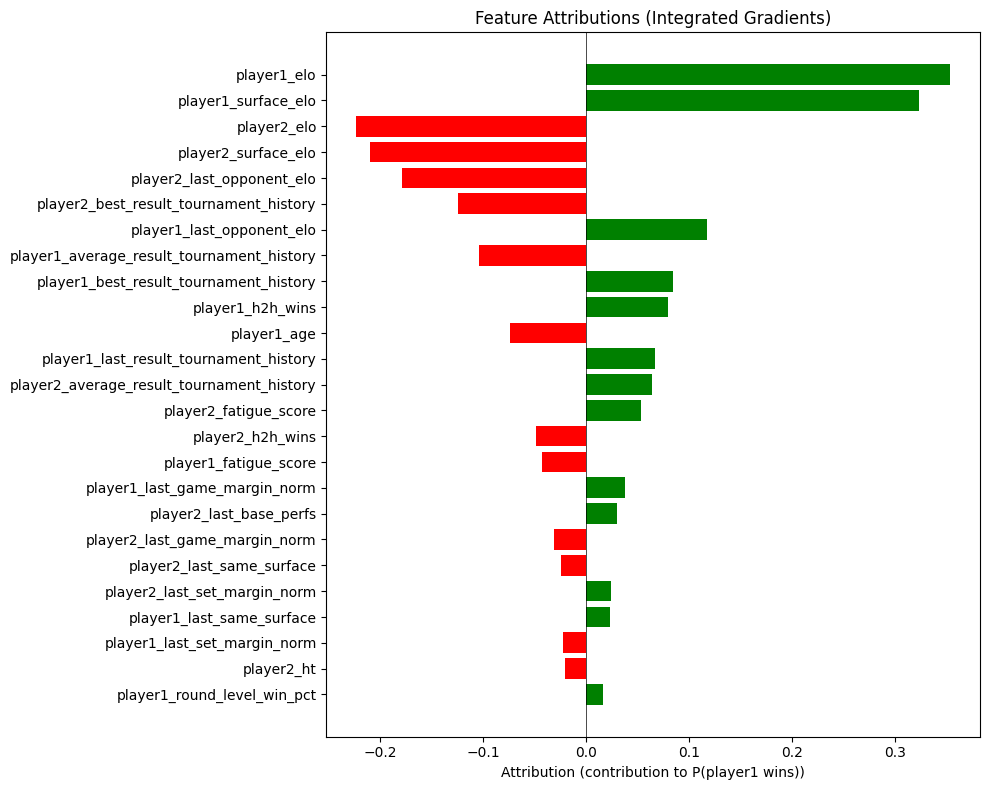

In [50]:
import matplotlib.pyplot as plt

def plot_attributions(attr_df, top_n=20, title="Feature Attributions (Integrated Gradients)"):
    subset = attr_df.head(top_n)
    colors = ['green' if a > 0 else 'red' for a in subset['attribution']]
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(range(len(subset)), subset['attribution'], color=colors)
    ax.set_yticks(range(len(subset)))
    ax.set_yticklabels(subset['feature'])
    ax.invert_yaxis()
    ax.set_xlabel('Attribution (contribution to P(player1 wins))')
    ax.set_title(title)
    ax.axvline(x=0, color='black', linewidth=0.5)
    
    plt.tight_layout()
    plt.show()
    plt.close(fig)

plot_attributions(atts_df, top_n=25)